In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import json
from math import pi
from datetime import timedelta

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

from Tools import Tools4DataExtraction as T4DE

In [2]:
D4NN= T4DE.Get_Data4NN_p()
atributo='FECHA_CORRIDA'
D4NN[atributo] = pd.to_datetime(D4NN[atributo])
fecha_maxima = D4NN[atributo].max()
dia_anterior = fecha_maxima - timedelta(days=1)
"""
fecha_inicio = dia_anterior - timedelta(days=364)
D4NN = D4NN[(D4NN[atributo] >= fecha_inicio) &
                    (D4NN[atributo] <= dia_anterior)].copy()
"""
D4NN = D4NN[(D4NN[atributo] <= dia_anterior)].copy()

#D4NN= D4NN[D4NN['TIPO_PASAJERO']=='AD'].copy()

Memoria usada antes: 629.32 MB
Memoria usada después: 122.26 MB
Reducción: 80.6%


# Algoritmo para Boletaje


📊 RESULTADOS XGBoost (Diferencias → Trend reconstruido):
RMSE : 21.49
MAPE : 8.18%
R²   : 0.9450


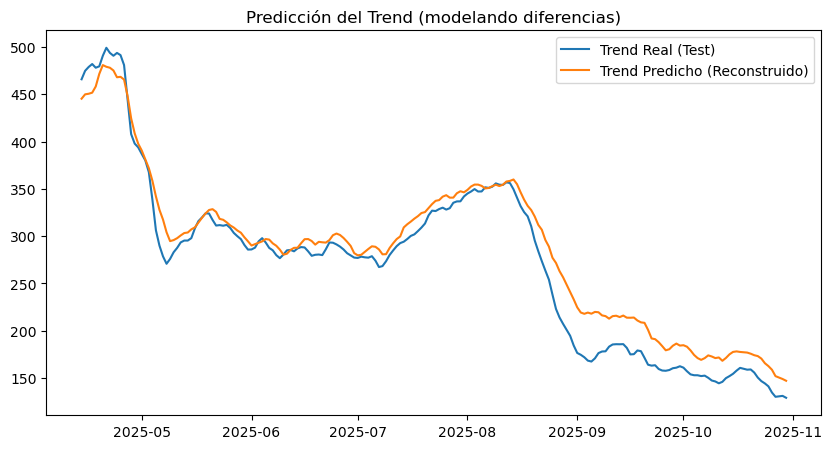


✅ PRONÓSTICO FUTURO (TREND)
            pred_trend
2025-10-31  126.657082
2025-11-01  124.652786
2025-11-02  123.715668
2025-11-03  121.799133
2025-11-04  118.290192
2025-11-05  115.946571
2025-11-06  113.403252
2025-11-07  110.317062
2025-11-08  107.186195
2025-11-09  104.685974
2025-11-10  101.417007
2025-11-11  100.540817
2025-11-12   99.680695
2025-11-13   97.327789
2025-11-14   95.481468


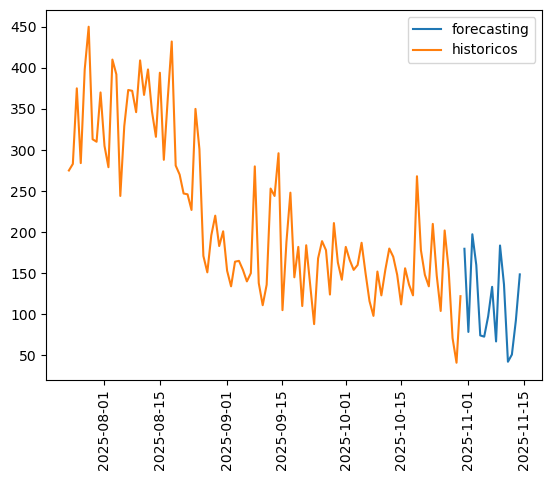

(175.99984273595703, 2.8212863520215974e-31, 213.88589472268112, 1.0052837977733267e-97)

--- GARCH(1,1) fit summary (dist='t') ---
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.005
Vol Model:                            GARCH   Log-Likelihood:               -816.613
Distribution:      Standardized Student's t   AIC:                           1641.23
Method:                  Maximum Likelihood   BIC:                           1654.42
                                              No. Observations:                  200
Date:                      Fri, Nov 07 2025   Df Residuals:                      200
Time:                              16:15:19   Df Model:                            0
                            Volatility Model                            
                 coef    std e

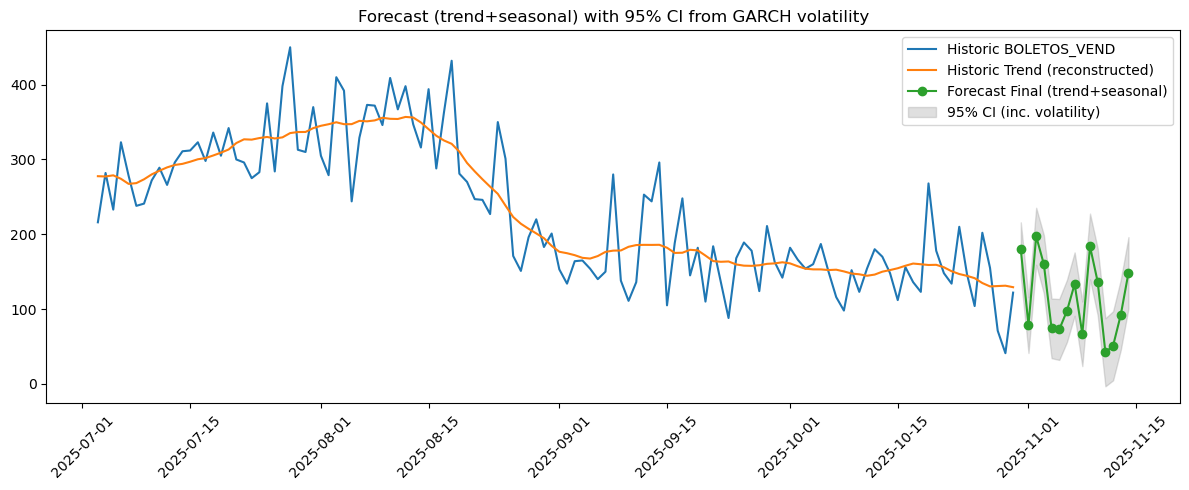

,BOLETOS_VEND,BOLETOS_VEND_FORE,forecast_final_lower,forecast_final_upper
FECHA_CORRIDA,,,,
2023-01-01,167.0,0.000000,0.000000,0.000000
2023-01-02,233.0,0.000000,0.000000,0.000000
2023-01-03,486.0,0.000000,0.000000,0.000000
2023-01-04,470.0,0.000000,0.000000,0.000000
2023-01-05,282.0,0.000000,0.000000,0.000000
...,...,...,...,...
2025-11-02,138.0,197.368793,159.240121,235.497465
2025-11-03,182.0,159.855734,120.841168,198.870299
2025-11-04,158.0,74.232410,34.351624,114.113195


In [3]:
# -------------------------
# Preparar datos base
# -------------------------
target_col= 'BOLETOS_VEND'
Frame = D4NN[['FECHA_CORRIDA',target_col,'MES','PORCENT_PROMO','FOP']].copy()

agg_dict = {col: 'mean' for col in Frame.columns if col not in ['FECHA_CORRIDA',target_col]}
agg_dict[target_col] = 'sum'

df = Frame.groupby('FECHA_CORRIDA').agg(agg_dict).reset_index()

df = df.set_index('FECHA_CORRIDA')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df_finalFore=pd.DataFrame()
df_finalFore[target_col]= df[target_col].copy()

# Descomposición (save trend)
result = seasonal_decompose(df[target_col], model='additive', period=14)
#resultV = seasonal_decompose(df['VENTA'], model='additive', period=14)
df['trend'] = result.trend
#df['VentaTrend'] = result.trend.diff()
df['DiaSemana'] = df.index.dayofweek

def Get_goodCarac(Df,BC_json):
    df=Df.copy()
    df['DiaMayorBoletaje'] = df['DiaSemana'].isin(BC_json["DiaBueno"])
    df['MesMayorBoletaje'] = df['MES'].isin(BC_json["MesBueno"])
    return df

ruta_principal = os.getcwd()
BuenasCarac_path = os.path.join(ruta_principal, "Files", "BuenaCaracteristicas.json")
with open(BuenasCarac_path, 'r') as f:
    #  Cargar el contenido del archivo JSON
    BC_json = json.load(f)
    
df= Get_goodCarac(df,BC_json)

# -------------------------
# Crear objetivo = diferencias del trend
# -------------------------
df['trend_diff'] = df['trend'].diff()

# -------------------------
# Lags y ventanas sobre las diferencias
# -------------------------
df["diff_lag1"]  = df["trend_diff"].shift(1)
df["diff_lag7"]  = df["trend_diff"].shift(7)
df["diff_lag30"] = df["trend_diff"].shift(30)

df["diff_ma7"]  = df["trend_diff"].rolling(7).mean()
df["diff_ma30"] = df["trend_diff"].rolling(30).mean()

# -------------------------
# Features de fecha cíclicas
# -------------------------
df["sin_mes"] = np.sin(2 * np.pi * df["MES"] / 12)
df["cos_mes"] = np.cos(2 * np.pi * df["MES"] / 12)
df["sin_dia"] = np.sin(2 * np.pi * df["DiaSemana"] / 7)
df["cos_dia"] = np.cos(2 * np.pi * df["DiaSemana"] / 7)

features = [
    "diff_lag1", "diff_lag7", "diff_lag30",
    "diff_ma7", "diff_ma30",
    "sin_dia", "cos_dia", "sin_mes", "cos_mes", 'DiaMayorBoletaje', 'MesMayorBoletaje',
    'PORCENT_PROMO','FOP'
]



# Quitar NaNs generados
df = df.dropna()

# -------------------------
# Selección de features
# -------------------------

X = df[features]
y = df["trend_diff"]

# -------------------------
# Train / Test temporal
# -------------------------
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# -------------------------
# Modelo XGBoost
# -------------------------
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

# -------------------------
# Predicción de diferencias
# -------------------------
y_pred_diff = model.predict(X_test)

# -------------------------
# Reconstrucción del trend nivel (reintegración)
# -------------------------
# Punto inicial = último trend conocido del train
last_trend_train = df['trend'].iloc[train_size - 1]

# Suma acumulada de diferencias + nivel inicial
trend_pred_level = np.cumsum(y_pred_diff) + last_trend_train

# Trend verdadero en el test (niveles)
trend_real_level = df["trend"].iloc[train_size:].values

# Index para graficar
idx_test = df.index[train_size:]

# -------------------------
# Métricas (comparando niveles)
# -------------------------
rmse  = np.sqrt(mean_squared_error(trend_real_level, trend_pred_level))
mape  = mean_absolute_percentage_error(trend_real_level, trend_pred_level) * 100
r2    = r2_score(trend_real_level, trend_pred_level)

print("\n📊 RESULTADOS XGBoost (Diferencias → Trend reconstruido):")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

# -------------------------
# Graficar resultado
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(idx_test, trend_real_level, label='Trend Real (Test)')
plt.plot(idx_test, trend_pred_level, label='Trend Predicho (Reconstruido)')
plt.title("Predicción del Trend (modelando diferencias)")
plt.legend()
plt.show()

# =======================================================
# PRONÓSTICO A FUTURO: AUTOREGRESIVO (15 días adelante)
# =======================================================

future_days = 15

# Crear dataframe futuro con fechas a partir de la última fecha
last_date = df.index[-1]
future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)

future_df = pd.DataFrame(index=future_index)

# ============================
# 1) VARIABLES DE CALENDARIO
# ============================
future_df["MES"] = future_df.index.month
future_df["DiaSemana"] = future_df.index.dayofweek

future_df["sin_mes"] = np.sin(2 * np.pi * future_df["MES"] / 12)
future_df["cos_mes"] = np.cos(2 * np.pi * future_df["MES"] / 12)
future_df["sin_dia"] = np.sin(2 * np.pi * future_df["DiaSemana"] / 7)
future_df["cos_dia"] = np.cos(2 * np.pi * future_df["DiaSemana"] / 7)

# ============================
# 2) Variables del JSON
# ============================
future_df["DiaMayorBoletaje"] = future_df["DiaSemana"].isin(BC_json["DiaBueno"])
future_df["MesMayorBoletaje"] = future_df["MES"].isin(BC_json["MesBueno"])

# ============================
# 3) Variables exógenas que tú tienes que definir:
# (PROMOCIONES y FOP hacia el futuro)
# PONER aquí los valores futuros o arrastrar últimos
# ============================

future_df["PORCENT_PROMO"] = df["PORCENT_PROMO"].iloc[-1]   # o reemplaza con tu forecast
future_df["FOP"] = df["FOP"].iloc[-1]                       # o reemplaza con tu forecast

# ============================
# 4) Predicción autoregresiva de tendencia
# ============================

last_trend = df["trend"].iloc[-1]
last_diff = df["trend_diff"].iloc[-1]

pred_diffs = []

for i in range(future_days):

    # Construir la fila de features usando los lags dinámicos
    row = pd.DataFrame({
        "diff_lag1":   [last_diff],
        "diff_lag7":   [df["trend_diff"].iloc[-7 + i] if i < 7 else pred_diffs[i-7]],
        "diff_lag30":  [df["trend_diff"].iloc[-30 + i] if i < 30 else pred_diffs[i-30]],
        "diff_ma7":    [df["trend_diff"].iloc[-7:].mean()],
        "diff_ma30":   [df["trend_diff"].iloc[-30:].mean()],
        "sin_dia":     [future_df["sin_dia"].iloc[i]],
        "cos_dia":     [future_df["cos_dia"].iloc[i]],
        "sin_mes":     [future_df["sin_mes"].iloc[i]],
        "cos_mes":     [future_df["cos_mes"].iloc[i]],
        "DiaMayorBoletaje": [future_df["DiaMayorBoletaje"].iloc[i]],
        "MesMayorBoletaje": [future_df["MesMayorBoletaje"].iloc[i]],
        "PORCENT_PROMO":    [future_df["PORCENT_PROMO"].iloc[i]],
        "FOP":              [future_df["FOP"].iloc[i]]
    })

    # predicción de diff
    pred_diff = model.predict(row)[0]
    pred_diffs.append(pred_diff)

    # actualización del último valor (para reintegrar nivel)
    last_trend = last_trend + pred_diff
    last_diff = pred_diff  # este se vuelve el lag1

# ============================
# Reconstrucción del nivel del trend para futuro
# ============================
future_df["pred_trend"] = np.cumsum(pred_diffs) + df["trend"].iloc[-1]

print("\n✅ PRONÓSTICO FUTURO (TREND)")
print(future_df[["pred_trend"]])

# Obtener últimos valores del componente estacional (periodo = 14)
period=future_days-1
last_seasonal = result.seasonal[-period:].values

# Repetir estacionalidad hasta cubrir los 15 días
seasonal_forecast = np.resize(last_seasonal, future_days)

# Agregar al DataFrame
future_df["forecast_final"] = future_df["pred_trend"].values + seasonal_forecast

plt.plot(future_df["forecast_final"],label='forecasting')
plt.plot(df[target_col][-100:],label='historicos')
plt.legend()
plt.xticks(rotation=90)
plt.show()

resid = trend_real_level - trend_pred_level

from statsmodels.stats.diagnostic import het_arch
print(het_arch(resid, nlags=12))


# -------------------------
# GARCH sobre residuos + intervalos para future_days
# -------------------------
from arch import arch_model
from scipy.stats import t as student_t
import warnings
warnings.filterwarnings("ignore")

# --- 1) RESIDUOS históricos (usar los que ya calculaste)
# resid = trend_real_level - trend_pred_level  # ya lo tienes en tu sesión
resid = (trend_real_level - trend_pred_level).astype(float)

# --- 2) Ajustar GARCH(1,1) con t-Student en la distribución de errores
# Usamos mean='Zero' porque los residuos deben tener media cercana a 0.
am = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='t')
garch_res = am.fit(disp='off')   # silent fit
print("\n--- GARCH(1,1) fit summary (dist='t') ---")
print(garch_res.summary())

# --- 3) Forecast de varianzas para future_days
garch_fore = garch_res.forecast(horizon=future_days, reindex=False)
# f.variance: DataFrame, última fila contiene var(1..h)
cond_var = garch_fore.variance.values[-1]   # array length = future_days
cond_var = np.array(cond_var, dtype=float)  # seguridad
cond_std = np.sqrt(cond_var)                # sigma_t for each horizon

# --- 4) obtener quantil t (si se estimó 'nu'), sino usar normal 1.96
use_t = False
multiplier = 1.96  # default z for 95%
nu = None
try:
    params = garch_res.params
    if 'nu' in params.index:
        nu = float(params['nu'])
        use_t = True
except Exception:
    use_t = False

if use_t and (nu is not None) and (nu > 2):
    # t-Student quantile for 97.5%
    multiplier = float(student_t.ppf(0.975, df=nu))
    note = f"Using t-quantile (nu={nu:.2f}) -> multiplier={multiplier:.3f}"
else:
    multiplier = 1.96
    note = "Using normal approx (z=1.96) as fallback"

print("\nNote:", note)

# --- 5) Construir intervalos sobre trend_predicted (niveles) y añadir volatilidad al future_df
trend_future = future_df["pred_trend"].values  # shape (future_days,)
upper = trend_future + multiplier * cond_std
lower = trend_future - multiplier * cond_std

future_df["volatility"] = cond_std
future_df["forecast_trend_upper"] = upper
future_df["forecast_trend_lower"] = lower

# --- 6) Asegurar seasonal_forecast tiene same length and add to get final forecast + intervals
# seasonal_forecast ya deberías tener (np.resize of last seasonal pattern). Si no, crear:
seasonal_period = 14  # ajusta si tu seasonal_decompose usó otro periodo
last_seasonal = result.seasonal[-seasonal_period:].values
seasonal_forecast = np.resize(last_seasonal, future_days)

future_df["seasonal"] = seasonal_forecast
# forecast_final: trend + seasonal
future_df["forecast_final"] = future_df["pred_trend"].values + future_df["seasonal"].values
future_df["forecast_final_upper"] = future_df["forecast_trend_upper"].values + future_df["seasonal"].values
future_df["forecast_final_lower"] = future_df["forecast_trend_lower"].values + future_df["seasonal"].values

# --- 7) Mostrar resultados y graficar
print("\nFuture forecast (trend ± 95% CI) and volatility:")
display_cols = ["pred_trend", "seasonal", "forecast_final", "volatility",
                "forecast_final_lower", "forecast_final_upper"]
print(future_df[display_cols])

# Graficar forecast final con intervalo
plt.figure(figsize=(12,5))
# plot historical last window for context
hist_plot_n = 120
plt.plot(df[target_col].index[-hist_plot_n:], df[target_col].values[-hist_plot_n:], label="Historic BOLETOS_VEND")
# plot reconstructed historical trend (last part) for context
plt.plot(df.index[-hist_plot_n:], df['trend'].values[-hist_plot_n:], label="Historic Trend (reconstructed)")


# future central and bands
plt.plot(future_df.index, future_df["forecast_final"], label="Forecast Final (trend+seasonal)", marker='o')
plt.fill_between(future_df.index,
                 future_df["forecast_final_lower"],
                 future_df["forecast_final_upper"],
                 color='gray', alpha=0.25, label="95% CI (inc. volatility)")

plt.xticks(rotation=45)
plt.legend()
plt.title("Forecast (trend+seasonal) with 95% CI from GARCH volatility")
plt.tight_layout()
plt.show()


df_finalFore[target_col+'_FORE']=0
df_finalFore['forecast_final_lower']=0
df_finalFore['forecast_final_upper']=0
df_finalFore[target_col+'_FORE'][df_finalFore.index>=future_df.index.min()]=future_df['forecast_final']
df_finalFore['forecast_final_lower'][df_finalFore.index>=future_df.index.min()]=future_df['forecast_final_lower']
df_finalFore['forecast_final_upper'][df_finalFore.index>=future_df.index.min()]=future_df['forecast_final_upper']

df_finalFore